# Probability & Statistics Lab 1: Naive Bayes Classifier

Work breakdown:
-   *Anna Kravchenko*;
-   *Inna Dermanska*;
-   *Illia Semochko*.

## Introduction

During the first three weeks, you learned a couple of essential notions
and theorems, and one of the most important among them is the **Bayes
theorem**:

$$
\mathsf P(A \mid B) = \frac{\mathsf P(A)\mathsf P(B \mid A)}{\mathsf P(B)}.
$$


**Naive Bayes Classifier** is a simple algorithm, which is based on
Bayes theorem and used for solving classification problems.

**Classification problem** is a problem in which an observation has to
be classified in one of the $n$ classes based on its similarity with
observations in each class.

It is a **probabilistic classifier**, which means it predicts based on
the probability of an observation belonging to each class. To compute
it, this algorithm uses **Bayes' formula** as:
$$
\mathsf P (\text{class}_i \mid \text{observation}) = \frac{\mathsf P(\text{class}_i) \mathsf P(\text{observation} \mid \text{class}_i)}{\mathsf P(\text{observation})}. \quad \quad (1)
$$
Breaking down the pieces of the formula,
- $\mathsf P(\text{class}_i)$ is referred to as a **prior** [distribution]: it provides initial class probabilities, influenced by prior beliefs about the problem.
- $\mathsf P(\text{observation} \mid \text{class}_i)$ is the **likelihood**: it tells how likely observations are for a chosen class.
- $\mathsf P(\text{observation})$ is the **evidence**; usually isn't computed directly and used as a normalization constant s.t. sum of $\mathsf P (\text{class}_i \mid \text{observation})$ for all classes is $1$.


This lab focuses on binary classification of text. Text can be considered a sequence of observations/features, with many ways to split it into individual/elementary features. Here, we split the text by words, and one word is considered a feature $\text{feature}_j$:
$\mathsf P(\text{text}) = \mathsf P(\text{features}_1, \text{feature}_2, \dots, \text{feature}_N) = \mathsf P(\text{features}_1)\cdot \mathsf P(\text{feature}_2 \mid \text{feature}_1) \cdot \mathsf P(\text{feature}_3 \mid (\text{feature}_1, \text{feature}_2)) \dots.$

However, modeling such long conditionals is complex, compute-intensive, and requires lots of data.

One way to deal with this is to assume independence, where one can write: $\mathsf P(\text{text}) = \prod_{j=1}^N \mathsf P(\text{feature}_j).$
Or, one could assume the dependence only on the previous word, which will be explored in the additional task!

$\mathsf P(\text{feature}_j)$ is unknown, and we estimate it empirically using the training data split. The empirical probability of some feature $x$ would be $\frac{\text{\# of } x}{\text{total \# of features}}.$
Note that such an approach would turn $\mathsf P(\text{text})$ to $0$ for any completely new feature (as its count among data is zero), which is undesirable.
A common way to deal with this is [Laplace smoothing](https://en.wikipedia.org/wiki/Additive_smoothing). No need to dive deeply into this now, as you will develop a better intuition as you progress through the course.
In this lab, you shall apply Laplace smoothing to both class priors and feature ($\log$–)probabilities.

#### Implementation note

Instead of storing and calculating probabilities directly, many ML solutions prefer computations in $\log$ domain. One of the reasons is numerical stability, which shows up in $\prod_{j=1}^N \mathsf P(\text{feature}_j)$:
each $\mathsf P(\text{feature}_j) \in (0, 1)$ in practice, resulting in tiny final product, which floating-point numbers the computer uses can't store as accurately.
However, in the logarithmic domain even $10^{-100}$ corresponds to an order of magnitude of $-100$.

So, let's rewrite the equation we estimate:
$$
\log [\mathsf P (\text{class}_i \mid \text{observation})] = \underbrace{\log[\mathsf P(\text{class}_i)] + \sum_{j=1}^N \log[\mathsf P(\text{feature}_j)]}_{\text{used to be a numerator, } L_i} - \overbrace{\log[\mathsf P(\text{observation})]}^{\text{used to be a denominator, log-evidence}}. \quad \quad (2)
$$


[A video example of a Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA).


### Outline of the work

1.  **Data preprocessing** (1 point)
2.  **Data visualization** (1 point)
3.  **Classifier implementation from scratch** (1.5 points)
4.  **Measurements of effectiveness of your classifier** (1.5 points)
5.  **Additional task** (up to 2 points, optional)


*Please submit a pre-executed `.ipynb` notebook for easier evaluation.*


### Data preprocessing

In [1]:
import pathlib
import pandas as pd
import numpy as np
import re
from collections import defaultdict


class Dataset:
    def __init__(self, dataset_dir_path: pathlib.Path):
        self.train_df = pd.read_csv(dataset_dir_path / "train.csv")
        self.test_df = pd.read_csv(dataset_dir_path / "test.csv")

        self.bag_of_words_per_label_id: dict[int, dict[str, int]] = {}
        self.bag_of_log_probabilities_per_label_id: dict[int, dict[str, float]] = {}

    def preprocess_text(self, stop_words: list[str]) -> None:
        """
        Adds "label-id" (starting with 0) and "useful-words" columns to dataframes.
        Useful words are the ones that aren't in the stop words list.
        Remove the punctuation, map all the text to one register (e.g., lowercase).

        You may add custom preprocessing if it's justified!
        """
        stop_words_set = set(stop_words)

        # 1. Мапінг текстових міток (label) у числові ідентифікатори (label-id) починаючи з 0
        unique_labels = sorted(self.train_df["label"].unique())
        label_to_id = {label: idx for idx, label in enumerate(unique_labels)}

        self.train_df["label-id"] = self.train_df["label"].map(label_to_id)
        if "label" in self.test_df.columns:
            self.test_df["label-id"] = self.test_df["label"].map(label_to_id)

        # 2. Функція очищення тексту від пунктуації, приведення до нижнього регістру та фільтрації стоп-слів
        def extract_useful_words(text: str) -> list[str]:
            if not isinstance(text, str):
                return []
            text = text.lower()
            text = re.sub(r"[^\w\s]", " ", text)
            words = text.split()
            useful = [w for w in words if w not in stop_words_set and len(w) > 1]
            return useful

        self.train_df["useful-words"] = self.train_df["tweet"].apply(
            extract_useful_words
        )
        self.test_df["useful-words"] = self.test_df["tweet"].apply(
            extract_useful_words
        )


    def calculate_classes_prior(self, smoothing_alpha: float) -> np.ndarray:
        """
        :param smoothing_alpha: parameter of Laplace smoothing.
        :return: distribution of classes after smoothing, starting with label-id 0.
        """
        label_counts = self.train_df["label-id"].value_counts().sort_index()
        num_classes = len(self.train_df["label-id"].unique())
        total_samples = len(self.train_df)

        # P(class_i) = (N_i + alpha) / (N + K * alpha)
        priors = (label_counts.values + smoothing_alpha) / (
            total_samples + num_classes * smoothing_alpha
        )
        return priors

    def compute_bag_of_words(self) -> None:
        """
        Counts the number of occurrences of each word per label id and updates `self.bag_of_words_per_label_id`.

        Bag of words intro: https://machinelearningmastery.com/gentle-introduction-bag-words-model/.
        Advice: you may use `collections.defaultdict` (https://docs.python.org/3/library/collections.html#collections.defaultdict).
        """
        bow = defaultdict(lambda: defaultdict(int))

        for _, row in self.train_df.iterrows():
            label_id = row["label-id"]
            words = row["useful-words"]
            for word in words:
                bow[label_id][word] += 1

        # Перетворення у звичайні словники
        self.bag_of_words_per_label_id = {
            label_id: dict(counts) for label_id, counts in bow.items()
        }


    def compute_bag_of_log_probabilities(self, smoothing_alpha: float) -> float:
        """
        Uses `self.bag_of_words_per_label_id` and updates `self.bag_of_log_probabilities_per_label_id`.
        `self.bag_of_log_probabilities_per_label_id` should store log[P(feature_j)].

        :param smoothing_alpha: parameter of Laplace smoothing.
        :return the log-probability of a new(previously unseen) feature, necessary for evaluation on the test set.
        """
        vocab = set()
        for word_counts in self.bag_of_words_per_label_id.values():
            vocab.update(word_counts.keys())
        vocab_size = len(vocab)

        self.bag_of_log_probabilities_per_label_id = {}
        unseen_log_probs = []

        for label_id, word_counts in self.bag_of_words_per_label_id.items():
            total_words_in_class = sum(word_counts.values())
            denominator = total_words_in_class + smoothing_alpha * vocab_size

            self.bag_of_log_probabilities_per_label_id[label_id] = {}

            # Обчислюємо лог-ймовірність для кожного слова зі словника V
            for word in vocab:
                count = word_counts.get(word, 0)
                prob = (count + smoothing_alpha) / denominator
                self.bag_of_log_probabilities_per_label_id[label_id][word] = np.log(
                    prob
                )

            # Лог-ймовірність для нового (невідомого) слова (count = 0)
            unseen_prob = smoothing_alpha / denominator
            unseen_log_probs.append(np.log(unseen_prob))

        return float(np.mean(unseen_log_probs))

discrimination_dataset_path = pathlib.Path("discrimination")  # change if needed.
discrimination_dataset = Dataset(discrimination_dataset_path)

labels = discrimination_dataset.train_df["label"].unique().tolist()
print(f"Labels are {labels}.")

Labels are ['discrim', 'neutral'].


Loading the stop words

In [2]:
stop_words_path = pathlib.Path("stop_words.txt")  # change if needed.

stop_words: list[str] = []
with open(stop_words_path) as f:
    for line in f:
        stop_words.extend(line.split())  # split(), because one line is "ours<TAB>ourselves"

print(f"Some of the stop words are {stop_words[:8]}.")

Some of the stop words are ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am'].


In [3]:
discrimination_dataset.preprocess_text(stop_words)
print(
    discrimination_dataset.train_df[["tweet", "label-id", "useful-words"]].head()
)

                                               tweet  label-id  \
0  #allahsoil the term jihad is a highly-conteste...         0   
1  @user @user and so called "moderate muslims" j...         1   
2   @user ramadan mubarak to all muslims all over...         1   
3  i love #abrahamhicks and #lawofattraction !!  ...         1   
4                 fatherâs day! #daddy #fathersday         1   

                                        useful-words  
0  [allahsoil, term, jihad, highly, contested, co...  
1  [user, user, called, moderate, muslims, just, ...  
2  [user, ramadan, mubarak, muslims, world, may, ...  
3  [love, abrahamhicks, lawofattraction, healthy,...  
4                  [fatherâ, day, daddy, fathersday]  


In [4]:
classes_alpha = 1.0
classes_prior = discrimination_dataset.calculate_classes_prior(classes_alpha)
log_classes_prior = np.log(classes_prior)
print(classes_prior)

[0.07030482 0.92969518]


In [5]:
discrimination_dataset.compute_bag_of_words()

In [6]:
features_alpha = 1.0
unseen_feature_log_prob = discrimination_dataset.compute_bag_of_log_probabilities(features_alpha)
print(
    f"Unseen feature log-probability: {unseen_feature_log_prob:.4f}"
)
print(
    "Vocabulary size per class:"
    f" {[len(v) for v in discrimination_dataset.bag_of_words_per_label_id.values()]}"
)

Unseen feature log-probability: -11.5106
Vocabulary size per class: [4830, 30940]


### Data visualization

Visualize the dataset, its properties, etc. You may use external libraries such as `matplotlib`, `plotly`, etc. Data analysis could provide hints/ideas for downstream classifier evaluation.

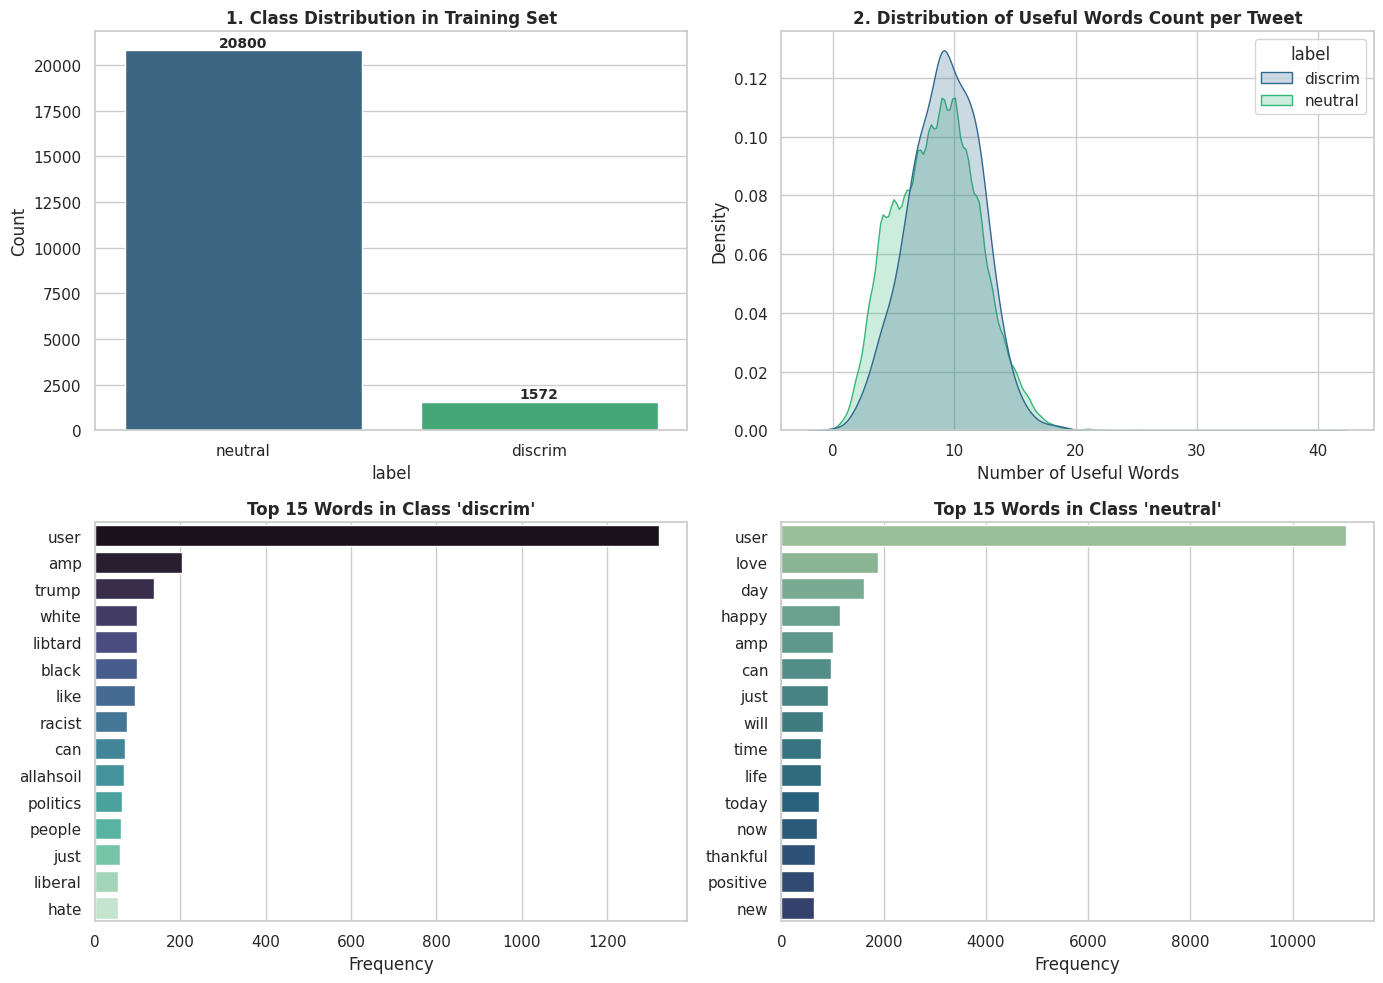

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

label_counts = discrimination_dataset.train_df["label"].value_counts()
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    ax=axes[0, 0],
    palette="viridis",
    hue=label_counts.index,
    legend=False,
)
axes[0, 0].set_title("1. Class Distribution in Training Set", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Count")
for i, count in enumerate(label_counts.values):
    axes[0, 0].text(i, count + 200, str(count), ha="center", fontsize=10, fontweight="bold")

discrimination_dataset.train_df["num_words"] = discrimination_dataset.train_df["useful-words"].apply(len)
sns.kdeplot(
    data=discrimination_dataset.train_df,
    x="num_words",
    hue="label",
    common_norm=False,
    fill=True,
    ax=axes[0, 1],
    palette="viridis",
)
axes[0, 1].set_title("2. Distribution of Useful Words Count per Tweet", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Number of Useful Words")
axes[0, 1].set_ylabel("Density")

#Top-15 найчастіших слів для кожного класу
for label_id, label_name in zip([0, 1], sorted(discrimination_dataset.train_df["label"].unique())):
    ax = axes[1, label_id]
    word_counts = discrimination_dataset.bag_of_words_per_label_id.get(label_id, {})
    top_words = Counter(word_counts).most_common(15)

    words, counts = zip(*top_words) if top_words else ([], [])

    sns.barplot(
        x=list(counts),
        y=list(words),
        ax=ax,
        palette="mako" if label_id == 0 else "crest",
        hue=list(words),
        legend=False,
    )
    ax.set_title(f"Top 15 Words in Class '{label_name}'", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

### Classifier implementation

Recall equation $(2)$. You will manually calculate the *"used to be a numerator"* part, call it $L_i$, for each class, while log-evidence is numerically safely calculated from an array of log-domain per-class numerators.


In [8]:
def compute_log_evidence(per_label_log_domain_numerator: np.ndarray) -> float:
    return np.logaddexp.reduce(per_label_log_domain_numerator)

#### Derivation of log-evidence calculation

Let $L_i = \log \mathsf P(\text{class}_i) + \sum_j \log \mathsf P(\text{feature}_j \mid \text{class}_i)$. By $(1)$, $\mathsf P(\text{class}_i \mid \text{obs}) = e^{L_i} / \mathsf P(\text{obs})$.
The posterior is a probability distribution over the classes, so it sums to $1$:
$$
1 = \sum_i \mathsf P(\text{class}_i \mid \text{obs}) = \frac{\sum_i e^{L_i}}{\mathsf P(\text{obs})}
\;\Longrightarrow\;
\log \mathsf P(\text{obs}) = \log \sum_i e^{L_i}.
$$

Computed directly, $e^{L_i}$ underflows to $0$ for long texts ($L_i$ is in the hundreds of negative units). The log-sum-exp trick avoids it: with $m = \max_i L_i$,
$$
\log \sum_i e^{L_i} = m + \log \sum_i e^{L_i - m},
$$
where the largest term is $e^0 = 1$. `np.logaddexp(a, b)` $= \log(e^a + e^b)$ is computed exactly this way, and since the sum is associative, `np.logaddexp.reduce` applies it to all $C$ numerators. The posterior is then $\exp(L_i - \text{log-evidence})$.

#### Prediction implementation

In [9]:
from typing import Literal


def compute_log_numerators(dataset: Dataset, split: Literal["train", "test"], log_prior: np.ndarray,
                           unseen_feature_log_prob: float) -> np.ndarray:
    """(NxC) array of L_i = log P(class_i) + sum_j log P(feature_j | class_i)."""
    df = dataset.train_df if split == "train" else dataset.test_df
    tables = [dataset.bag_of_log_probabilities_per_label_id[i] for i in sorted(dataset.bag_of_log_probabilities_per_label_id)]
    return np.array([
        [log_prior[k] + sum(table.get(w, unseen_feature_log_prob) for w in words) for k, table in enumerate(tables)]
        for words in df["useful-words"]
    ])


def predict(dataset: Dataset, split: Literal["train", "test"], log_prior: np.ndarray,
            unseen_feature_log_prob: float) -> np.ndarray:
    """
    "train" split option may be useful for debugging.
    :return: the (NxC) array of predicted probabilities, where N is the number of texts, and C is the number of classes.
    """
    numerators = compute_log_numerators(dataset, split, log_prior, unseen_feature_log_prob)
    return np.array([np.exp(row - compute_log_evidence(row)) for row in numerators])


train_probs = predict(discrimination_dataset, "train", log_classes_prior, unseen_feature_log_prob)
print("rows sum to 1:", np.allclose(train_probs.sum(axis=1), 1.0),
      "| train accuracy:", (train_probs.argmax(axis=1) == discrimination_dataset.train_df["label-id"]).mean())

rows sum to 1: True | train accuracy: 0.9737618451635973


### Classifier evaluation

Note that accuracy is not always a good metric for the classifier. One may look at precision and recall curves, F1 score metric, ROC curves.

When evaluating the model, it's important to understand the
different types of classification results:

-   A ***true positive***(TP) result is one where the model correctly
    predicts the positive class.
-   A ***true negative***(TN) result is one where the model correctly
    predicts the negative class.
-   A ***false positive***(FP) result is one where the model incorrectly
    predicts the positive class when it is actually negative.
-   A ***false negative***(FN) result is one where the model incorrectly
    predicts the negative class when it is actually positive.

Precision measures the proportion of true positive predictions among all positive predictions made by the model: $\text{Precision} = \frac{TP}{TP+FP}.$

Recall measures the proportion of true positives identified out of all actual positive cases: $\text{Recall} = \frac{TP}{TP+FN}$.


F1 score is the harmonic mean of both precision and recall: $\text{F1} = \frac{2\times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}.$

See [this link](https://cohere.com/blog/classification-eval-metrics) to find more information about metrics.

Visualize plots and show failure cases.

In [10]:
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)

# label-id 0 = "discrim" is the positive class. The data is imbalanced (~93% neutral), so we care about
# precision / recall / F1 of "discrim". The smoothing alpha of the features is chosen on a validation part
# of the TRAIN set (the test set is used only once, afterwards).
train_full, test_df = discrimination_dataset.train_df, discrimination_dataset.test_df
is_val = np.random.default_rng(42).random(len(train_full)) < 0.2
sub_train, val = train_full[~is_val], train_full[is_val]

val_ds = Dataset(discrimination_dataset_path)
val_ds.train_df, val_ds.test_df = sub_train, val
val_ds.compute_bag_of_words()
log_prior_sub = np.log(val_ds.calculate_classes_prior(classes_alpha))

for alpha in [0.03, 0.1, 0.3, 1.0]:
    unseen = val_ds.compute_bag_of_log_probabilities(alpha)
    pred = predict(val_ds, "test", log_prior_sub, unseen).argmax(axis=1)
    print(f"features_alpha={alpha:<5} validation F1 (discrim) = {f1_score(val['label-id'] == 0, pred == 0):.3f}")

features_alpha=0.03  validation F1 (discrim) = 0.708
features_alpha=0.1   validation F1 (discrim) = 0.721
features_alpha=0.3   validation F1 (discrim) = 0.709


features_alpha=1.0   validation F1 (discrim) = 0.579


Accuracy of 'always neutral': 0.930   Accuracy of Naive Bayes: 0.959

              precision    recall  f1-score   support

     discrim      0.707     0.712     0.710       671
     neutral      0.978     0.978     0.978      8918

    accuracy                          0.959      9589
   macro avg      0.843     0.845     0.844      9589
weighted avg      0.959     0.959     0.959      9589

ROC AUC = 0.957 | average precision = 0.784


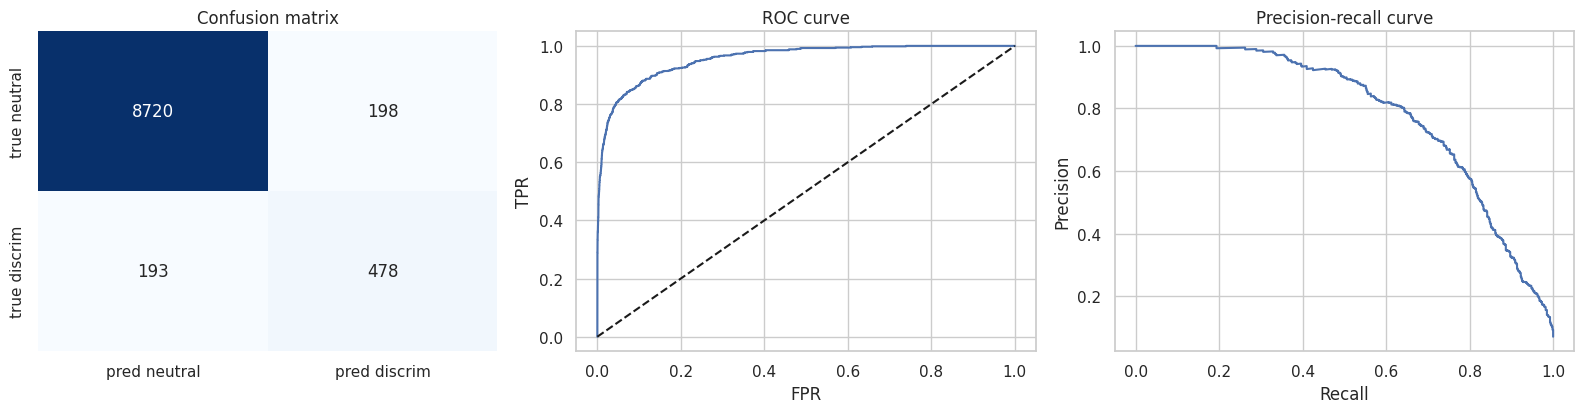

In [11]:
import matplotlib.pyplot as plt

best_alpha = 0.1  # best value from the validation table above
unseen_final = discrimination_dataset.compute_bag_of_log_probabilities(best_alpha)  # fitted on the full train set
test_probs = predict(discrimination_dataset, "test", log_classes_prior, unseen_final)
y_true, y_pred = test_df["label-id"].values, test_probs.argmax(axis=1)
p_discrim = test_probs[:, 0]

print(f"Accuracy of 'always neutral': {np.mean(y_true == 1):.3f}   Accuracy of Naive Bayes: {np.mean(y_true == y_pred):.3f}\n")
print(classification_report(y_true, y_pred, target_names=["discrim", "neutral"], digits=3))
print(f"ROC AUC = {roc_auc_score(y_true == 0, p_discrim):.3f} | average precision = {average_precision_score(y_true == 0, p_discrim):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
sns.heatmap(confusion_matrix(y_true == 0, y_pred == 0), annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["pred neutral", "pred discrim"], yticklabels=["true neutral", "true discrim"])
axes[0].set_title("Confusion matrix")
fpr, tpr, _ = roc_curve(y_true == 0, p_discrim)
axes[1].plot(fpr, tpr); axes[1].plot([0, 1], [0, 1], "k--"); axes[1].set(title="ROC curve", xlabel="FPR", ylabel="TPR")
prec, rec, _ = precision_recall_curve(y_true == 0, p_discrim)
axes[2].plot(rec, prec); axes[2].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
plt.tight_layout(); plt.show()

In [12]:
# Failure cases: the most confident mistakes.
pd.set_option("display.max_colwidth", 130)
errors = test_df[["tweet"]].assign(true=np.where(y_true == 0, "discrim", "neutral"), P_discrim=p_discrim)
print("False negatives (discrim tweets the model is sure are neutral):")
display(errors[(y_true == 0) & (y_pred == 1)].sort_values("P_discrim").head(5).round(4))
print("False positives (neutral tweets the model is sure are discrim):")
display(errors[(y_true == 1) & (y_pred == 0)].sort_values("P_discrim", ascending=False).head(5).round(4))

False negatives (discrim tweets the model is sure are neutral):


,tweet,true,P_discrim
901,@user how do you sleep at night? you are a terrible person! you sir represent everything wrong with our country. gfy,discrim,0.0
7949,bout to spend new year's eve playing the game lol,discrim,0.0
8048,one powerful picture. it takes great humanity and kindness to save the life of someone who hates your existenceâ¦,discrim,0.0
7264,all together this christmas: pls &amp; follow @user national day of action on 20 feb against &amp; theâ¦,discrim,0.0
7262,#alexpascal was #friend of my late daddy and my #music teacher. @user @user @user eu easteuropeans are,discrim,0.0


False positives (neutral tweets the model is sure are discrim):


,tweet,true,P_discrim
418,#lgbtqhatestrumppay but luvs homophobic misogynist antisemitic death cult masquerading as a religion. !,neutral,1.0
2748,@user how did you slip through? you are a threat to america ! #bigotry #misogyny #ignorance #alwaystrup @user,neutral,1.0
8414,@user @user @user that's the problem...he doesn't even realize that mentioning the judges ethnicity is racist!,neutral,1.0
9166,liberals are the most intolerant. they accuse conservatives of hate but they are full of hate and intolerance. !,neutral,1.0
9587,"#fatherhood is the bst thng tat cud hapn 2 me,&amp; i'm just glad i can share my voic #dwyane wade #fathersday ...",neutral,1.0


**Results.** Accuracy is misleading here: always answering "neutral" already gives 93.0%, and the model reaches 95.9%. The informative numbers are those of the *discrim* class: precision 0.71, recall 0.71, F1 0.71 (ROC AUC 0.957, average precision 0.78 against 0.07 for a random classifier). Smoothing matters: with `alpha = 1` the small discrim class is smoothed too strongly towards the 31k-word vocabulary (validation F1 0.58); `alpha = 0.1` was best (0.72).

**Failure cases.** Naive Bayes counts words and ignores context, so the false positives are mostly tweets that *talk about* racism or hate using the same words as hateful tweets (e.g. "ethnicity is racist"). The false negatives are discriminating tweets without any typical keywords (insults, sarcasm, or possibly noisy labels). The predicted probabilities are almost always 0 or 1: the independence assumption makes the model overconfident, so only the ranking of the scores (the curves), not the probability values, should be trusted.

### Additional task

You are asked to explore, implement, evaluate, and analyze another way to calculate $\mathsf P(\text{text})$; mainly, by conditioning on the previous feature:
$$
\mathsf P(\text{text}) = \prod_{j=2}^N \mathsf P(\text{feature}_j \mid \text{feature}_{j-1}).
$$

The task will be graded proportionally to analysis depth and conclusions viability.

In [13]:
from collections import Counter


class BigramNB:
    """P(text | class) = prod_j P(w_j | w_{j-1}, class), with add-alpha smoothing and a start token <s>."""

    def fit(self, df):
        self.bigrams = {c: Counter() for c in (0, 1)}   # (previous, current) -> count
        self.contexts = {c: Counter() for c in (0, 1)}  # previous -> count
        for c, words in zip(df["label-id"], df["useful-words"]):
            seq = ["<s>"] + list(words)
            self.bigrams[c].update(zip(seq[:-1], seq[1:]))
            self.contexts[c].update(seq[:-1])
        self.V = len({w for c in (0, 1) for (_, w) in self.bigrams[c]})
        return self

    def predict_proba(self, df, log_prior, alpha):
        probs = []
        for words in df["useful-words"]:
            seq = ["<s>"] + list(words)
            L = np.array([log_prior[c] + sum(
                np.log((self.bigrams[c][pair] + alpha) / (self.contexts[c][pair[0]] + alpha * self.V))
                for pair in zip(seq[:-1], seq[1:])) for c in (0, 1)])
            probs.append(np.exp(L - compute_log_evidence(L)))
        return np.array(probs)


# choose alpha on the validation split, then fit on the full train set and evaluate on the test set
bigram_val = BigramNB().fit(sub_train)
y_val = val["label-id"].values
for alpha in [0.01, 0.1, 1.0]:
    pred = bigram_val.predict_proba(val, log_prior_sub, alpha).argmax(axis=1)
    print(f"bigram alpha={alpha:<5} validation F1 (discrim) = {f1_score(y_val == 0, pred == 0):.3f}")

bigram alpha=0.01  validation F1 (discrim) = 0.412
bigram alpha=0.1   validation F1 (discrim) = 0.521


bigram alpha=1.0   validation F1 (discrim) = 0.372


In [14]:
best_bigram_alpha = 0.1  # best value from the validation table above
bigram_full = BigramNB().fit(train_full)
bigram_probs = bigram_full.predict_proba(test_df, log_classes_prior, best_bigram_alpha)
seen = set(bigram_full.bigrams[0]) | set(bigram_full.bigrams[1])
test_bigrams = [p for ws in test_df["useful-words"] for p in zip(["<s>"] + ws[:-1], ws)]
print(f"Test bigrams never seen in training: {np.mean([p not in seen for p in test_bigrams]):.1%}\n")

rows = {}
for name, probs in {"unigram": test_probs, "bigram": bigram_probs}.items():
    pred = probs.argmax(axis=1)
    rows[name] = {"precision": precision_score(y_true == 0, pred == 0), "recall": recall_score(y_true == 0, pred == 0),
                  "F1": f1_score(y_true == 0, pred == 0), "ROC AUC": roc_auc_score(y_true == 0, probs[:, 0]),
                  "avg precision": average_precision_score(y_true == 0, probs[:, 0])}
display(pd.DataFrame(rows).T.round(3))

Test bigrams never seen in training: 57.9%



,precision,recall,F1,ROC AUC,avg precision
unigram,0.707,0.712,0.710,0.957,0.784
bigram,0.821,0.423,0.559,0.873,0.581


**Bigram model** (`P(feature_j | feature_{j-1})`, add-alpha smoothing, with a start token `<s>` so the first word is also used). It is clearly worse than the unigram model: F1 0.56 vs 0.71, ROC AUC 0.87 vs 0.96. The reason is **sparsity**: 58% of the test bigrams never occur in training (only about 12% of the words are unseen), so for most positions the model has no evidence and relies on smoothing; the effect is strongest for the small discrim class. Its precision is higher (0.82) but recall drops to 0.42, i.e. it only recognises tweets that reuse known phrases. Tweets are short (about 9 useful words), the class signal is mostly in single words, and 22k tweets are too few for a table of $|V|^2$ bigrams. Better smoothing (back-off, Kneser-Ney, interpolation with the unigram model) or much more data would be needed for bigrams to help.

### Conclusions

**Method.** A Naive Bayes classifier for text, written from scratch. By Bayes' theorem $\mathsf P(\text{class}_i \mid \text{text}) = \mathsf P(\text{class}_i)\,\mathsf P(\text{text} \mid \text{class}_i) / \mathsf P(\text{text})$. The naive assumption, that words are independent given the class, turns the likelihood into $\prod_j \mathsf P(\text{word}_j \mid \text{class}_i)$. The probabilities are estimated by counting words in the training set, with Laplace smoothing $\frac{\#w + \alpha}{\#\text{words in class} + \alpha |V|}$ so that unseen words do not make the product zero. Everything is computed in the log domain ($L_i = \log \mathsf P(\text{class}_i) + \sum_j \log \mathsf P(w_j \mid \text{class}_i)$), and the evidence is $\log \sum_i e^{L_i}$, computed with `np.logaddexp` (log-sum-exp). The predicted class is the one with the largest $L_i$. On the test set the discrim class gets precision 0.71, recall 0.71, F1 0.71, ROC AUC 0.957.

**Pros and cons.** *Pros:* simple, training is only counting, fast, works with little data, few hyper-parameters, and the decisions are interpretable (word probabilities). *Cons / assumptions:* the independence assumption is false for language (word order, negation, context and sarcasm are ignored), so correlated words count as repeated evidence and the probabilities are overconfident. The model assumes train and test come from the same distribution, and words unseen in training carry no information. The result depends on the preprocessing (stop words, no stemming, hashtags treated as ordinary words), on the smoothing parameter, and on the class imbalance. It cannot tell *talking about* discrimination from *being* discriminating (see the false positives), and the labels are noisy. The bigram variant showed that a richer model is not automatically better when data is sparse.

**Accuracy vs. F1.** With imbalanced classes accuracy is dominated by the majority class: here "always neutral" has 93% accuracy but finds no discriminating tweet, and the real classifier improves accuracy by only 3 points while recall goes from 0 to 0.71. Accuracy also treats both error types as equally costly. Precision and recall look at the class we care about and expose false positives and false negatives separately, and F1, their harmonic mean, is high only if both are high, so it cannot be inflated by the majority class.